# Imports and utils

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [ ]:
if 'google.colab' in str(get_ipython()): # running in colab
    !git clone --config lfs.fetchinclude="*"  https://github.com/sinc-lab/xvalRNAfolding.git
    DATA_PATH = './xvalRNAfolding/'
else:
    DATA_PATH = '../'

In [ ]:
DIST_PATH =  DATA_PATH + "data/rnadist_f_all.h5"
d = pd.read_hdf(DIST_PATH)
dist = d / d.max().max()

In [ ]:
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.4
plt.rcParams['ytick.minor.width'] = 0.4
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5

font_size = 5 # max 7
linew = 0.8

strip_colors = sns.color_palette("tab10") # n_colors=Nfolds just remove the last 10-Nfolds colors
nshift = 8
strip_colors = strip_colors[nshift:] + strip_colors[:nshift]

In [ ]:
def get_ids(dist, split, fold, partition):
    """
    Obtains the common IDs between the distance matrix and a given partition
    """
    f = split.query("fold_number == @fold")
    part = f.query("partition == @partition")
    return sorted(set(dist.index) & set(part["id"]))


def get_partition_distances(dist, split, fold, partition1, partition2):
    """
   Retrieves the distance matrix between two partitions
   rows: IDs of the first partition
   cols: IDs of the second partition
    """
    rows = get_ids(dist, split, fold, partition1)
    cols = get_ids(dist, split, fold, partition2)
    return dist.loc[rows, cols].copy()

def create_dfs(splits, verbose=False):
    splits["partition"] = splits["partition"].apply(
    lambda x: "train" if x in ["train", "valid"] else "test"
    )
    folds = splits.fold_number.unique()
    parts = list(splits.partition.unique())

    dfs = {fold : {s: {p: pd.DataFrame() for p in parts} for s in parts} for fold in folds}
    for fold in folds:
        for p1 in parts:
            for p2 in parts:
                dfs[fold][p1][p2] = get_partition_distances(dist, splits, fold, p1, p2)
                if verbose:
                    print(f"Fold {fold} - {p1} vs {p2}: {dfs[fold][p1][p2].shape}")
    return dfs

In [ ]:
def plot_distribs(x_vals_list, y_vals_list, labels, fig_width,
                  x_label="Test-to-train structural distance",
                  colors=None, linew=0.8, font_size=5, text_shift=0.0):

    fig_height = 6.75/2/4

    fig = plt.figure(figsize=(fig_width, fig_height), dpi=150)
    ax = plt.gca()

    x_width = 1.0
    gap = 0.05 * x_width
    delta = x_width + gap

    y_max_global = max(np.max(y) for y in y_vals_list)

    for i, (x, y) in enumerate(zip(x_vals_list, y_vals_list)):
        x_shifted = x + i * delta - 0.01
        plt.plot(x_shifted, y, color=colors[i], lw=linew, label=str(labels[i]))
        ax.xaxis.set_visible(False)
        ymin, ymax = ax.get_ylim()
        # vertical separators
        if i < len(x_vals_list) - 1:
            x_div = (i + 1) * delta - gap / 2
            vline_ymax = ymin + 0.15*y_max_global
            ax.vlines(x_div, ymin, vline_ymax, colors="black", linewidth=0.5, zorder=4)
        if i == 0:
            ax.vlines(0, ymin, y_max_global, colors="black", linewidth=0.5, zorder=4)
            ax.set_ylim(ymin, y_max_global)

    txt = fig.text(
        0.05+text_shift, 0.08, x_label,
        fontsize=font_size, ha="left", va="bottom" )
    txt.set_in_layout(False)

    plt.yticks([])
    plt.xlim(0, (len(x_vals_list) - 1) * delta + x_width)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()


# Random k-fold

In [ ]:
splits_kfold = pd.read_csv(DATA_PATH +"data/random_kfolds_split.csv")
folds_kfold = splits_kfold.fold_number.unique()
folds_kfold.sort()
dfs_kfold = create_dfs(splits_kfold, verbose=False)
dfs_dists_kfold = {}
for fold in folds_kfold:
    rows = []
    mat = dfs_kfold[fold]['train']['test']
    vals = mat.to_numpy().ravel()
    rows.extend({
        "dist": float(v)
    } for v in vals)
    dfs_dists_kfold[fold] = pd.DataFrame(rows)

In [ ]:
kde_kfold = [None] * len(folds_kfold)
y_vals_kfold = [None] * len(folds_kfold)
x_vals_kfold = [None] * len(folds_kfold)
for i, fold in enumerate(folds_kfold):
    df = dfs_dists_kfold[fold]
    kde_kfold[i] = gaussian_kde(df['dist'])

    x_vals_kfold[i] = np.linspace(0, 1, 200)
    y_vals_kfold[i] = kde_kfold[i](x_vals_kfold[i])
    x_max = x_vals_kfold[i][np.argmax(y_vals_kfold[i])]

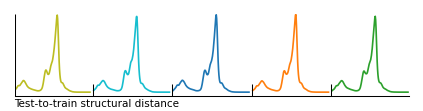

In [ ]:
fig_width1col = 6.75/2 - 0.45

plot_distribs(x_vals_kfold, y_vals_kfold, folds_kfold, fig_width1col,
              colors=strip_colors, linew=linew, font_size=font_size)

plt.savefig(DATA_PATH + "figures/Fig_random_kfolds_distributions.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_random_kfolds_distributions.png", bbox_inches='tight', dpi=300)

# Clustering fold

In [ ]:
splits_clust = pd.read_csv(DATA_PATH +"data/clustering_folds_split.csv")
folds_clust = splits_clust.fold_number.unique()
folds_clust.sort()
dfs_clust = create_dfs(splits_clust, verbose=False)
dfs_dists_clust = {}
for fold in folds_clust:
    mat = dfs_clust[fold]['train']['test']
    vals = mat.to_numpy().ravel()
    dfs_dists_clust[fold] = pd.DataFrame({"dist": vals})

In [ ]:
kde_clust = [None] * len(folds_clust)
y_vals_clust = [None] * len(folds_clust)
x_vals_clust = [None] * len(folds_clust)
for i, fold in enumerate(folds_clust):
    df = dfs_dists_clust[fold]
    kde_clust[i] = gaussian_kde(df['dist'])
    x_vals_clust[i] = np.linspace(0, 1, 200)
    y_vals_clust[i] = kde_clust[i](x_vals_clust[i])

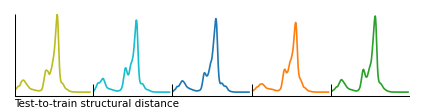

In [ ]:
fig_width1col = 6.75/2 - 0.45

plot_distribs(x_vals_clust, y_vals_clust, folds_clust, fig_width1col,
              colors=strip_colors, linew=linew, font_size=font_size)

plt.savefig(DATA_PATH + "figures/Fig_clustering_fold_distributions.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_clustering_fold_distributions.png", bbox_inches='tight', dpi=300)

# Family fold

In [ ]:
splits_fam = pd.read_csv(DATA_PATH +"data/fam_folds_split.csv")
folds_fam = splits_fam.fold_number.unique()
folds_fam.sort()
dfs_fam = create_dfs(splits_fam, verbose=False)
dfs_dists_fam = {}
for fold in folds_fam:
    mat = dfs_fam[fold]['train']['test']
    vals = mat.to_numpy().ravel()
    dfs_dists_fam[fold] = pd.DataFrame({"dist": vals})

In [ ]:
kde_fam = [None] * len(folds_fam)
y_vals_fam = [None] * len(folds_fam)
x_vals_fam = [None] * len(folds_fam)
for i, fold in enumerate(folds_fam):
    df = dfs_dists_fam[fold]
    kde_fam[i] = gaussian_kde(df['dist'])
    x_vals_fam[i] = np.linspace(0, 1, 200)
    y_vals_fam[i] = kde_fam[i](x_vals_fam[i])

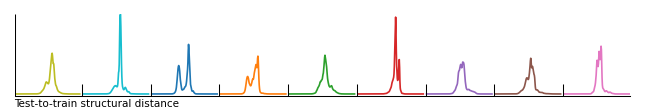

In [ ]:
fig_width1col = 6.75/3*2 * 1.1 - 0.55

plot_distribs(x_vals_fam, y_vals_fam, folds_fam, fig_width1col,
              colors=strip_colors, linew=linew, font_size=font_size, text_shift=-0.017)

plt.savefig(DATA_PATH + "figures/Fig_family_fold_distributions.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_family_fold_distributions.png", bbox_inches='tight', dpi=300)

# Human learned fold

In [ ]:
splits_hl = pd.read_csv(DATA_PATH +"data/hl_folds_split.csv")
folds_hl = splits_hl.fold_number.unique()
folds_hl.sort()
# Selecciona solo los 9 folds válidos (pares)
folds_hl = folds_hl[::2]  # 0,2,4,6,8,10,12,14,16
dfs_hl = create_dfs(splits_hl, verbose=False)
dfs_dists_hl = {}
for fold in folds_hl:
    mat = dfs_hl[fold]['train']['test']
    vals = mat.to_numpy().ravel()
    dfs_dists_hl[fold] = pd.DataFrame({"dist": vals})

In [ ]:
kde_hl = [None] * len(folds_hl)
y_vals_hl = [None] * len(folds_hl)
x_vals_hl = [None] * len(folds_hl)
for i, fold in enumerate(folds_hl):
    df = dfs_dists_hl[fold]
    kde_hl[i] = gaussian_kde(df['dist'])
    x_vals_hl[i] = np.linspace(0, 1, 200)
    y_vals_hl[i] = kde_hl[i](x_vals_hl[i])

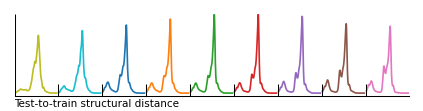

In [ ]:
fig_width1col = 6.75/2 - 0.45

plot_distribs(x_vals_hl, y_vals_hl, folds_hl, fig_width1col,
              colors=strip_colors, linew=linew, font_size=font_size)

plt.savefig(DATA_PATH + "figures/Fig_hlml_fold_distributions.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_hlml_fold_distributions.png", bbox_inches='tight', dpi=300)

# Similarity fold

In [ ]:
splits_path_sim = DATA_PATH +"data/sim_folds_split/"
splits_list_sim = os.listdir(splits_path_sim)
splits_list_sim.sort()
splits_sim = {}
for split in splits_list_sim:
    splits_sim[split] = pd.read_csv(splits_path_sim+split)
folds_sim = splits_sim[splits_list_sim[1]].fold_number.unique()
folds_sim.sort()
for split in splits_list_sim:
    splits_sim[split]["partition"] = splits_sim[split]["partition"].apply(
        lambda x: "train" if x in ["train", "valid"] else "test"
    )
parts_sim = list(splits_sim[split].partition.unique())
splits_sim[splits_list_sim[0]].partition.unique()
dfs_sim = {split : {s: {p: pd.DataFrame() for p in parts_sim} for s in parts_sim} for split in splits_list_sim}
for split in splits_list_sim:
    for p1 in parts_sim:
        for p2 in parts_sim:
            dfs_sim[split][p1][p2] = get_partition_distances(dist, splits_sim[split], 0, p1, p2)
dfs_dists_sim = {}
for split in splits_list_sim:
    rows = []
    for part1, dic in dfs_sim[split].items():
        for part2, mat in dic.items():
            if part1 != part2:
                vals = mat.to_numpy().ravel()
                rows.extend({
                    "part1": part1,
                    "part2": part2,
                    "dist": float(v)
                } for v in vals)
    dfs_dists_sim[split] = pd.DataFrame(rows)

In [ ]:
splits_list_sim=splits_list_sim[1:] # starting in sim40

In [ ]:
kde_sim_list = [None] * len(splits_list_sim)
x_sim_list = [None] * len(splits_list_sim)
y_sim_list = [None] * len(splits_list_sim)
for i, split in enumerate(splits_list_sim):
    df = dfs_dists_sim[split]
    kde_sim_list[i] = gaussian_kde(df['dist'])
    x_sim_list[i] = np.linspace(0, 1, 200)
    y_sim_list[i] = kde_sim_list[i](x_sim_list[i])

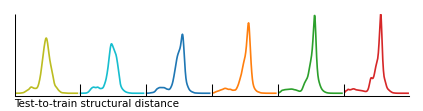

In [ ]:
fig_width1col = 6.75/2 - 0.45

plot_distribs(x_sim_list, y_sim_list, splits_list_sim, fig_width1col,
              colors=strip_colors, linew=linew, font_size=font_size)

plt.savefig(DATA_PATH + "figures/Fig_similarity_fold_distributions.pdf", bbox_inches='tight', dpi=300)
plt.savefig(DATA_PATH + "figures/Fig_similarity_fold_distributions.png", bbox_inches='tight', dpi=300)